In [118]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Exercício 1

1. Gere uma amostra de tamanho $K$ de uma variável com distribuição binomial negativa com parâmetros $p$ $r$ utilizando os três métodos vistos em sala: via Bernoullis, via soma de geométricas, via recursão.
2. Compare com uma amostra gerada pelo numpy usando histogramas.
3. Compare o tempo dos três métodos como visto nos labs anteriores.



## 1.1.1 Via Bernoulli

In [102]:
r = 10
p = .5
K = 1000
def neg_bin_via_bern(r,p, K):
    bin_neg = []
    for _ in range(K):
        n = 0
        s = 0
        while s < r:
            U = np.random.uniform()
            n += 1
            s += U < p
        bin_neg.append(n)
    return bin_neg

## 1.1.2 Via soma de geométricas

In [103]:
def neg_bin_via_geo(r,p,K):
    unis = np.random.uniform(size = (K,r))
    geos = np.ceil(np.log(unis)/np.log(1-p))
    bin_neg = np.sum(geos, axis=1)
    return bin_neg

## 1.1.3 Via recursão

In [107]:
def neg_bin_via_rec(r,p,K):
    bin_neg = []
    for _ in range(K):
        U = np.random.uniform()
        n = r
        pi = p**r
        F = pi
        while U > F:
            pi = pi*n*(1-p)/(n-r+1)
            n += 1
            F += pi
        bin_neg.append(n)
    return bin_neg

## 1.2 Conclusões

In [112]:
bin_neg_bern = neg_bin_via_bern(r,p, K)
bin_neg_geo = neg_bin_via_geo(r,p,K)
bin_neg_rec = neg_bin_via_rec(r,p,K)

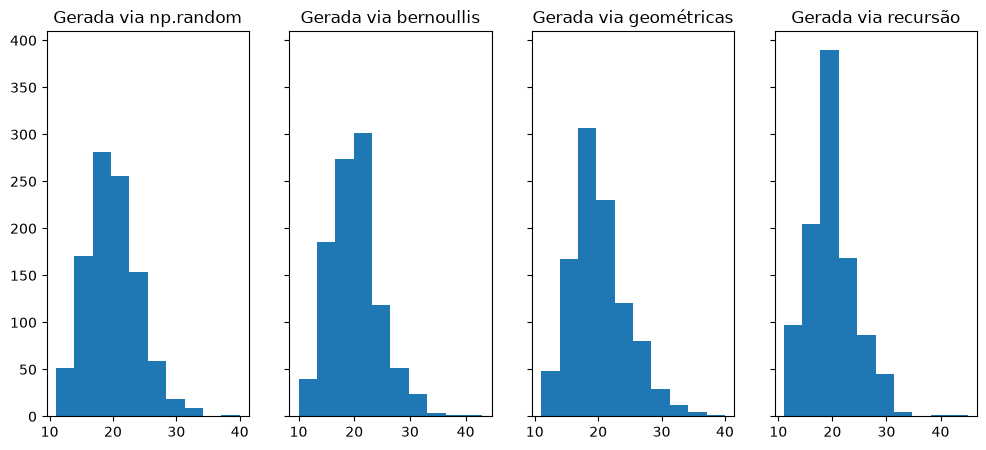

In [113]:
fig, ax = plt.subplots(1,4, figsize=(12,5), sharey=True)
ax[0].hist(np.random.negative_binomial(r,p,size = K) + r)
ax[0].set_title('Gerada via np.random')
ax[1].hist(bin_neg_bern)
ax[1].set_title('Gerada via bernoullis')
ax[2].hist(bin_neg_geo)
ax[2].set_title('Gerada via geométricas')
ax[3].hist(bin_neg_rec)
ax[3].set_title('Gerada via recursão')
plt.show()

In [111]:
# Médias
print(f'Média teórica: 20')
print(f'Média via bernoulli: {np.mean(bin_neg_bern)}')
print(f'Média via geométricas: {np.mean(bin_neg_geo)}')
print(f'Média via recursão: {np.mean(bin_neg_rec)}')
print(np.mean(np.random.negative_binomial(r,p, size =K))+r)

Média teórica: 20
Média via bernoulli: 19.841
Média via geométricas: 20.114
Média via recursão: 19.854
19.925


## 1.3

In [119]:
ps = np.linspace(0.05,0.9)
tempo_bernoullis = []
for p in ps:
    inicio = time.time()
    neg_bin_via_bern(r,p,K)
    tempo_bernoullis.append(time.time()-inicio)

In [120]:
tempo_geometricas=[]
for p in ps:
    inicio = time.time()
    neg_bin_via_geo(r,p,K)
    tempo_geometricas.append(time.time()-inicio)

In [121]:
tempo_recursao=[]
for p in ps:
    inicio = time.time()
    neg_bin_via_rec(r,p,K)
    tempo_recursao.append(time.time()-inicio)

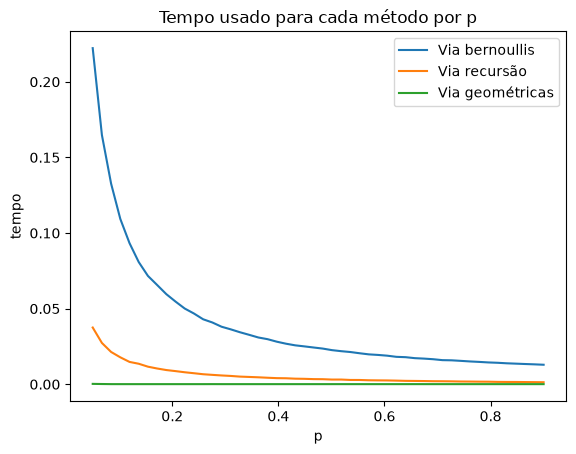

In [131]:
fig, ax = plt.subplots()
ax.plot(ps,tempo_bernoullis, label='Via bernoullis')
ax.plot(ps, tempo_recursao, label='Via recursão')
ax.plot(ps, tempo_geometricas, label='Via geométricas')
plt.xlabel('p')
plt.legend()
plt.ylabel('tempo')
plt.title('Tempo usado para cada método por p')
plt.show()

# Exercício 2

1.  Gere uma amostra de tamanho $K$ de uma variável aleatória com distribuição hipergeométrica com parâmetros $M,N,n$ utilizando o método de embaralhamento de Fisher–Yates.
2.  No método de Fisher-Yates, no passo (a), a gente amostra um ponto para troca entre $i$ e $N$. Pense em qual seria o problema caso a gente sempre amostrasse entre $1$ e $N$. Compare o resultado final usando essas duas versões e uma amostra gerada pelo numpy.

# Exercício 3

É intuitivo esperar que, quando o tamanho total da população $M+N$ cresce muito em relação ao tamanho da amostra $n$, o fato de a amostragem ser feita sem reposição passe a ter pouca importância, pois retirar um elemento altera muito pouco a composição da população restante. Nesse caso, cada retirada deve se comportar aproximadamente como um ensaio de Bernoulli independente, com probabilidade de sucesso

$$
p=\frac{N}{M+N}.
$$

Assim, esperamos que a distribuição hipergeométrica com parâmetros $M,N,n$ se aproxime de uma distribuição binomial com parâmetros $n$ e $p$.

Compare numericamente essas duas distribuições para valores crescentes de $M$ e $N$, mantendo aproximadamente constante a proporção

$$
\frac{N}{M+N}\to p,
$$

e mantendo $n$ fixo. Verifique, por meio de simulações, se a aproximação pela distribuição binomial melhora à medida que $M+N$ aumenta.
